Import needed libraries and modules

In [1]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from qiskit.quantum_info import random_unitary
from qiskit_aer import AerSimulator
import mthree

/home/lukas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Define needed quantum gates

In [2]:
def fourier_gate(d):
    """
    Generates a Fourier Transform gate for a d-dimensional system.
    F|j> = 1/sqrt(d) * sum_k (omega^(jk) |k>)
    """
    omega = np.exp(2j * np.pi / d)
    F = np.zeros((d, d), dtype=complex)
    for j in range(d):
        for k in range(d):
            F[k, j] = omega**(j * k) / np.sqrt(d)
    return F

def sum_gate(d):
    """
    Generates a SUM gate for a d-dimensional system (qudits).
    SUM|j>|k> = |j>|(j + k) mod d> 
    """
    dim = d**2
    SUM = np.zeros((dim, dim), dtype=complex)
    for j in range(d):
        for k in range(d):
            inp = j + k * d
            out = j + d * ((j + k) % d)
            SUM[out, inp] = 1
    return SUM

def x_gate(d):
    """
    Generates a genaralized X gate.
    X = sum_j |(j+1)%d><j|
    """
    X = np.zeros((d, d), dtype=complex)
    for j in range(d):
        X[(j + 1) % d, j] = 1
    return X

def z_gate(d):
    """
    Generates a generalized Z gate.
    Z = sum_j omega^j |j><j|
    """
    omega = np.exp(2j * np.pi / d)
    Z = np.zeros((d, d), dtype=complex)
    for j in range(d):
        Z[j, j] = omega**j
    return Z

Define the quantum teleportation circuit for general dimension d

In [3]:
def create_teleportation_circuit(d, seed=None):
    """
    Creates a quantum circuit for teleporting a d-dimensional state (qudit).
    """
    # Check if d is a power of 2 for qubit mapping
    if (d & (d - 1)) != 0:
        raise ValueError("Dimension d must be a power of 2 for qubit mapping.")
    # Initialize Gates for dimension d
    F = fourier_gate(d)
    SUM = sum_gate(d)
    X = x_gate(d)
    Z = z_gate(d)

    # Define registers and circuit
    # We map each qudit to log2(d) qubits, so we need log2(d) qubits for psi, A, and B each
    bits = int(np.log2(d))
    psi = QuantumRegister(bits, "psi")
    A = QuantumRegister(bits, "A")
    B = QuantumRegister(bits, "B")
    cr_n = ClassicalRegister(bits, "n")
    cr_m = ClassicalRegister(bits, "m")
    cr_z = ClassicalRegister(bits, "z")
    qc = QuantumCircuit(psi, A, B, cr_n, cr_m, cr_z)

    # Prepare completely UNKNOWN/RANDOM state psi
    U_prep = random_unitary(d, seed=seed)
    qc.unitary(U_prep, psi, label="U")
    qc.barrier()

    # We entangle Alice's and Bob's qudits mapped to log2​(d) qubits using the SUM and F gate
    qc.unitary(F, A, label=f"F{d}")
    qc.unitary(SUM, [*A,*B], label=f"SUM{d}")
    qc.barrier()

    # Now we apply the inverse of SUM and F gates to Alice's qudits mapped to log2​(d) qubits
    qc.unitary(SUM.conj().T, [*psi,*A], label=f"SUM{d}†")
    qc.unitary(F.conj().T, psi, label=f"F{d}†")
    qc.barrier()

    # Now Alice measures her qudits mapped to log2​(d) qubits
    qc.measure(psi, cr_n)
    qc.measure(A, cr_m)

    # We apply the necessary gates to Bob's unknown state based on Alice's measurement results
    # Create all possible powers of X and Z for corrections
    X_powers = [np.linalg.matrix_power(X,i) for i in range(d)]
    Z_powers = [np.linalg.matrix_power(Z,i) for i in range(d)]
    # Apply Z^n correction based on n register
    for n in range(1, d):
        with qc.if_test((cr_n, n)):
            qc.unitary(Z_powers[n], B, label=f"Z^{n}")
    # Apply X^-m correction based on m register
    for m in range(1, d):
        with qc.if_test((cr_m, m)):
            qc.unitary(X_powers[-m], B, label=f"X^-{m}")
    qc.barrier()

    # Finally, we apply the inverse of u to Bob's qudit mapped to log2​(d) qubits and measure for verification of the teleportation
    qc.unitary(U_prep.adjoint(), B, label="U†")
    qc.measure(B, cr_z)
    return qc

Create the quantum circuit for dimension 4

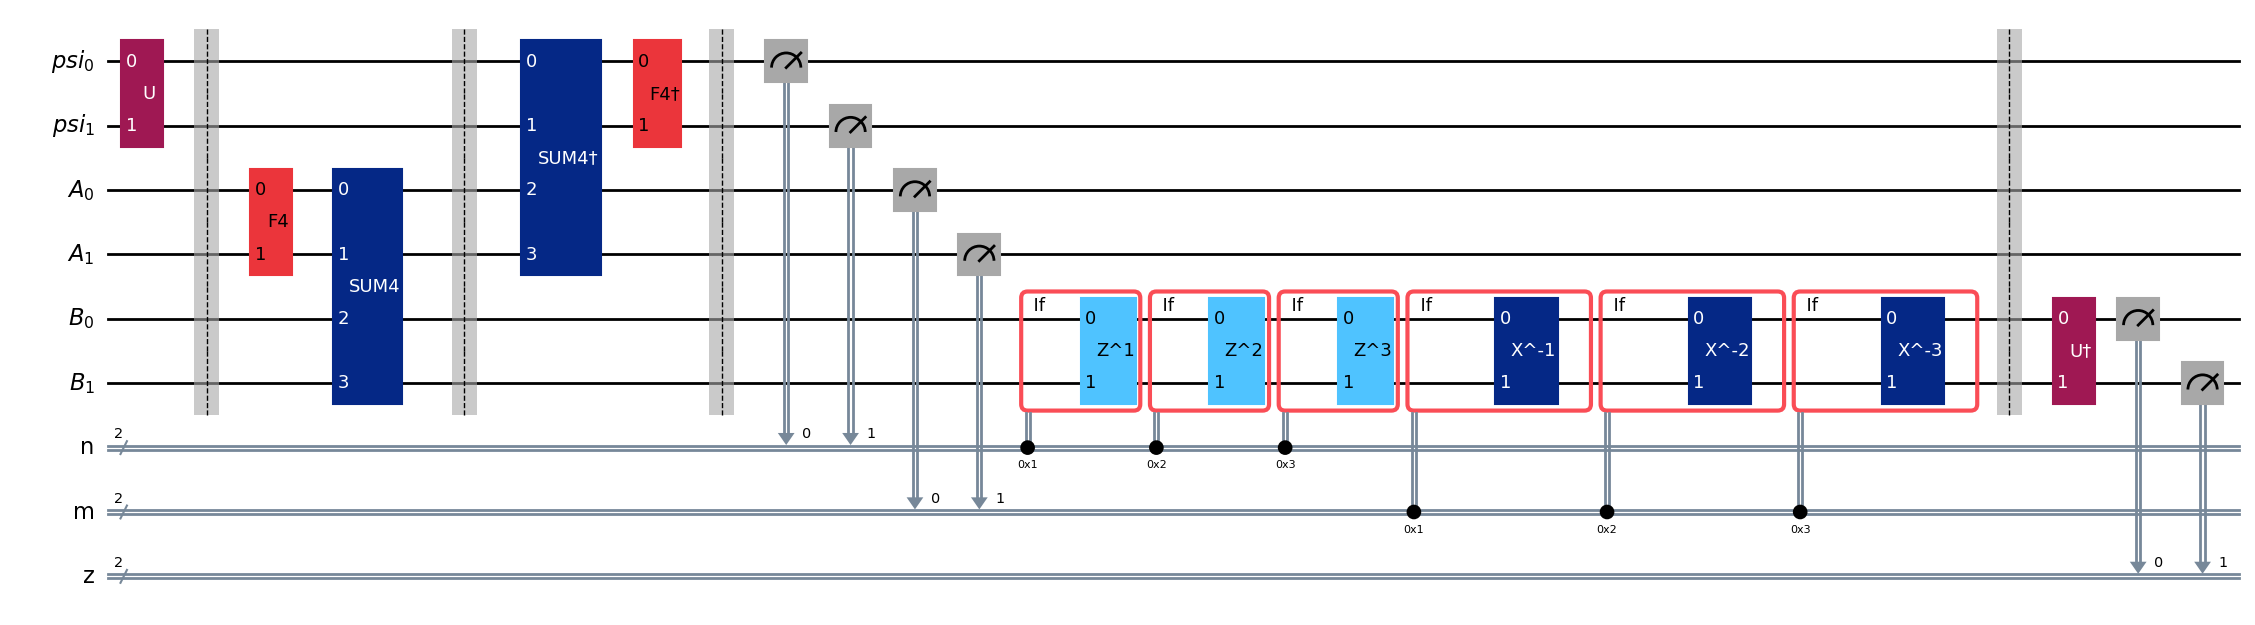

In [4]:
# Creating and visualizing the teleportation circuit for d=4 (2 qubits per qudit)
d = 4
qc = create_teleportation_circuit(d, seed=42)
style = {
    "displaycolor": {
        f"F{d}":   ("#EB353B", "black"),
        f"F{d}†":   ("#EB353B", "black"),
        f"SUM{d}": ("#052886", "white"),
        f"SUM{d}†": ("#052886", "white"),
        **{f"Z^{n}":  ("#4FC3FF", "black") for n in range(d)},
        **{f"X^-{m}": ("#052886", "white") for m in range(d)},
    }
}
fig = qc.draw(output="mpl", fold=100, style=style)
fig.savefig("results/circuit_qudit.png", dpi=600, bbox_inches="tight")
display(fig)

Optional code to run the circuit on simulator

In [15]:
# Initialize the AerSimulator and run on simulator
# sampler = SamplerV2(mode=AerSimulator())
# job = sampler.run([qc], shots=1024)
# res = job.result()

Run the teleportation protocol on real quantum hardware the IBM Kingston

In [36]:
# Initialize runtime service and backend
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
# Optimize circuit for backend
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
# Run circuit using Sampler
sampler = SamplerV2(mode=backend)
job = sampler.run([qc_isa])
res = job.result()

Process measurement counts and plot teleportation outcomes.

Success rate: 65.97%


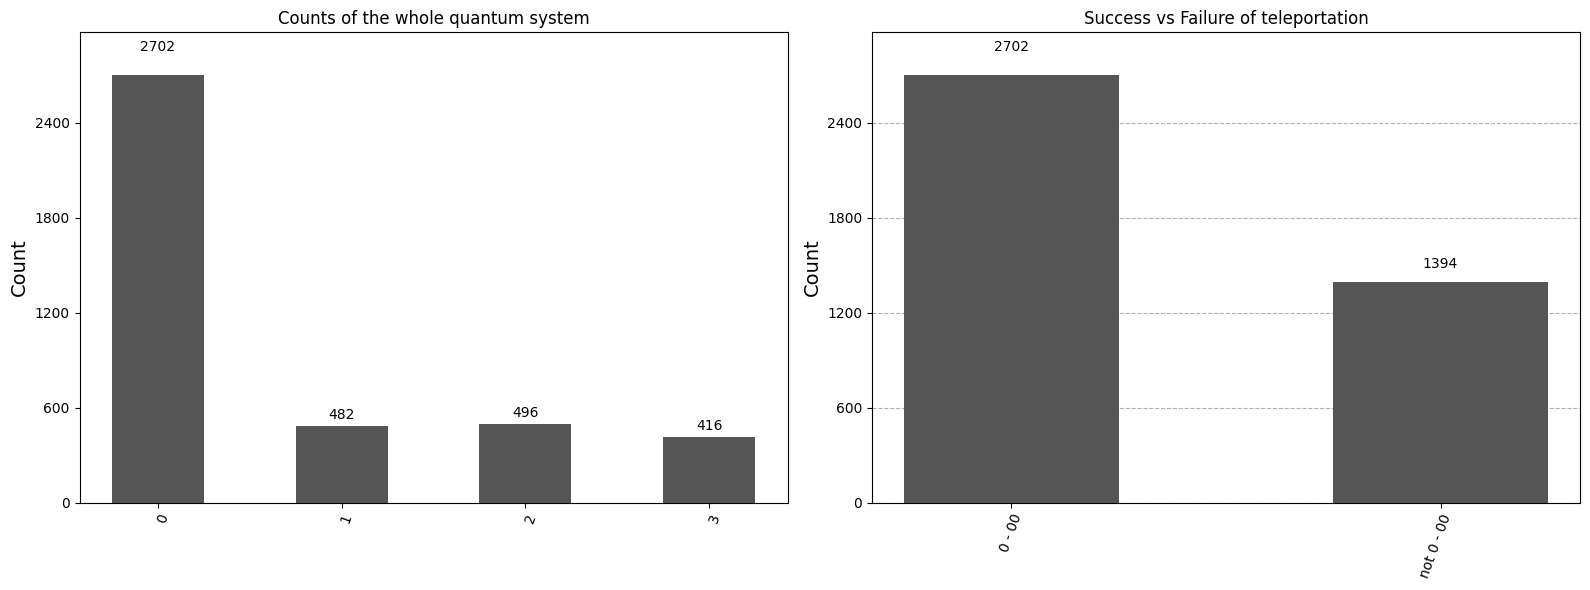

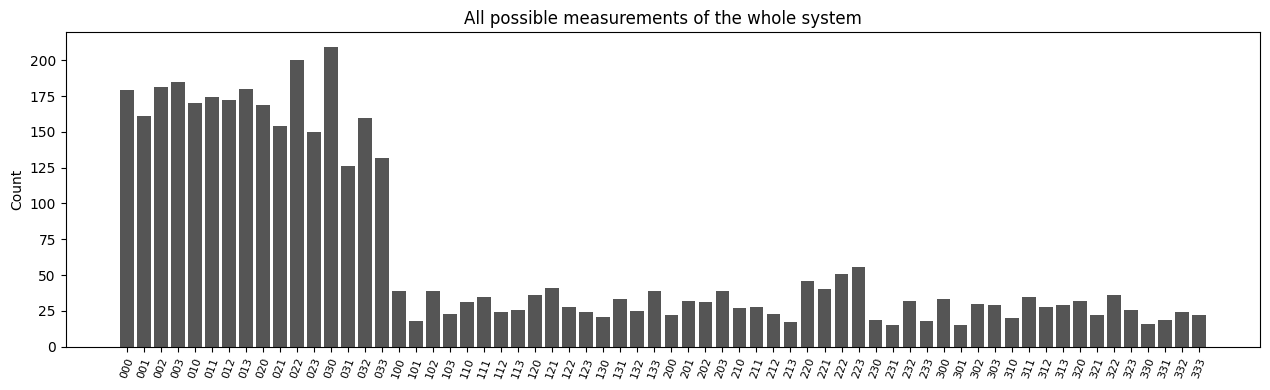

In [37]:
data = res[0].data
bits = int(np.log2(d))
counts = {}

bob_data = {str(i): 0 for i in range(d)}
all_states_data = {f"{z}{m}{n}": 0 for z in range(d) for m in range(d) for n in range(d)}

# Process all results in a single concise loop
for m_val, n_val, z_val in zip(data.m.get_bitstrings(), data.n.get_bitstrings(), data.z.get_bitstrings()):
    counts[z_val + m_val + n_val] = counts.get(z_val + m_val + n_val, 0) + 1
    
    z_v, m_v, n_v = str(int(z_val, 2)), str(int(m_val, 2)), str(int(n_val, 2))
    bob_data[z_v] += 1
    all_states_data[f"{z_v}{m_v}{n_v}"] += 1

total_shots = sum(counts.values())
success_count = bob_data.get('0', 0)
zero_str = f" - {'0' * bits}"
sf_data = { f"0{zero_str}": success_count, f"not 0{zero_str}": total_shots - success_count }

# Plot 1 & 2: Bob's State and Success metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_histogram(bob_data, ax=ax1, color='#555555')
ax1.set_title("Counts of the whole quantum system") 
plot_histogram(sf_data, ax=ax2, color='#555555', title="Success vs Failure of teleportation")
print(f"Success rate: {100 * success_count / total_shots:.2f}%")
plt.tight_layout()
fig.savefig("results/qudit_kingston_prob.png", dpi=600)
plt.show()

# Plot 3: All possible measurements
fig2 = plt.figure(figsize=(max(12, len(all_states_data) * 0.2), 4))
plt.bar(all_states_data.keys(), all_states_data.values(), color='#555555')
plt.title("All possible measurements of the whole system")
plt.xticks(rotation=70, fontsize=8)
plt.ylabel("Count")
plt.tight_layout()
fig2.savefig("results/qudit_kingston_all.png", dpi=600)
plt.show()

Run the M3Mitigation on the result of the teleportation protocol

In [38]:
mit = mthree.M3Mitigation(backend)

# Mapping: classical bit index -> measured physical qubit
qubit_mapping = mthree.utils.final_measurement_mapping(qc_isa)
bits = int(np.log2(d))

# Build qubit list in classical-bit order
qubit_list = [qubit_mapping[i] for i in sorted(qubit_mapping)]

# calibration using the ordered physical qubits and apply the mitigation
mit.cals_from_system(qubit_list)
quasi = mit.apply_correction(counts, qubit_list)

print("Physical qubits used in classical-bit order:", qubit_list)
print(quasi)

Physical qubits used in classical-bit order: [46, 45, 47, 57, 67, 68]
{'000000': np.float32(0.04297959), '000001': np.float32(0.03931701), '000010': np.float32(0.04366122), '000011': np.float32(0.045719467), '000100': np.float32(0.040904414), '000101': np.float32(0.042945977), '000110': np.float32(0.041819487), '000111': np.float32(0.04479376), '001000': np.float32(0.040825102), '001001': np.float32(0.038170714), '001010': np.float32(0.049170163), '001011': np.float32(0.03740701), '001100': np.float32(0.051540285), '001101': np.float32(0.03131866), '001110': np.float32(0.039309397), '001111': np.float32(0.033098232), '010000': np.float32(0.009127392), '010001': np.float32(0.004035632), '010010': np.float32(0.009218678), '010011': np.float32(0.00533847), '010100': np.float32(0.0072191674), '010101': np.float32(0.008367402), '010110': np.float32(0.0054931734), '010111': np.float32(0.006099863), '011000': np.float32(0.008489962), '011001': np.float32(0.009979852), '011010': np.float32(0.0

Plot the mitigated result to the raw counts.

--- Teleportation Success Metric ---
Raw:       0.6597
Mitigated: 0.6630
Improvement: +0.33%


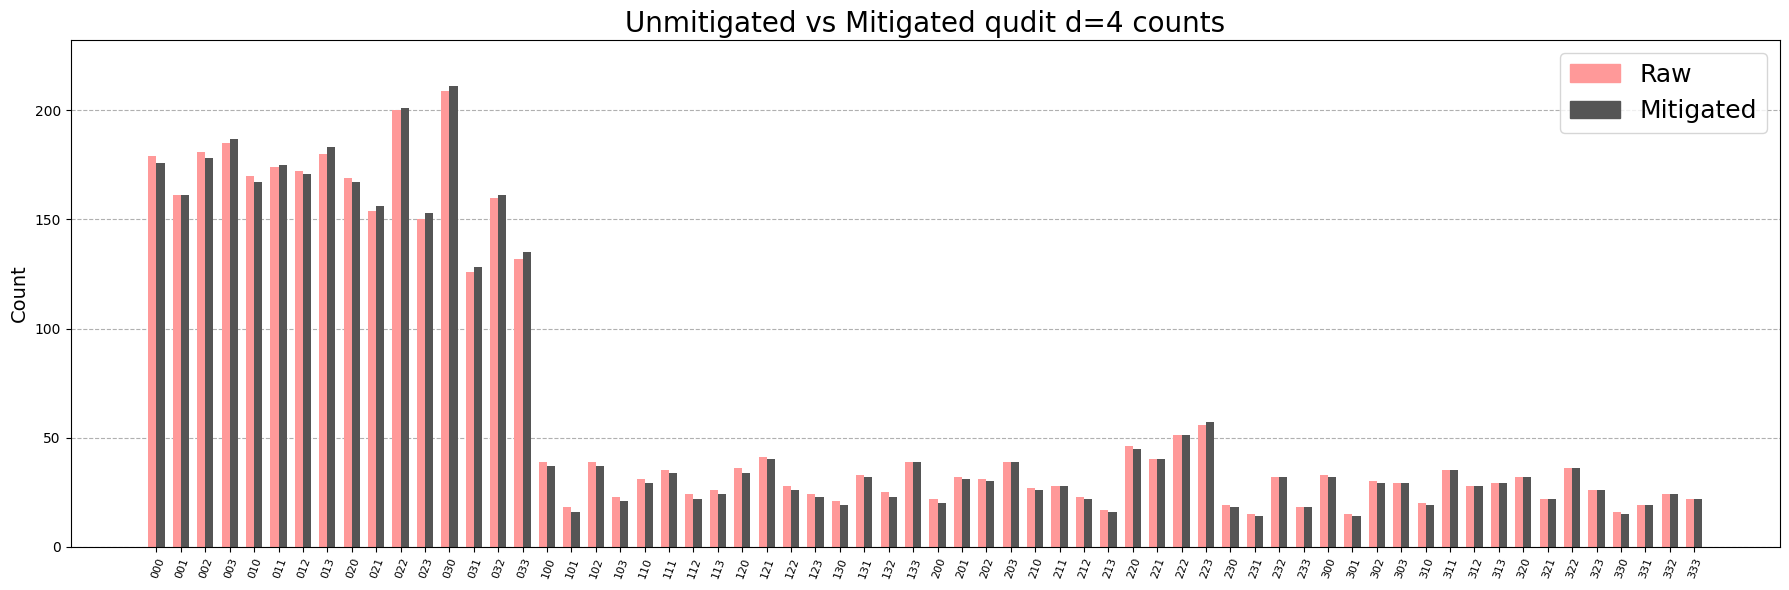

In [51]:
probs = quasi.nearest_probability_distribution()
bits = int(np.log2(d))

mitigated_probs_mapped = {}
mitigated_bob_probs = {str(i): 0.0 for i in range(d)}

for k, v in probs.items():
    z_bin = k[0:bits]
    m_bin = k[bits:2*bits]
    n_bin = k[2*bits:3*bits]

    mapped = f"{int(z_bin, 2)}{int(m_bin, 2)}{int(n_bin, 2)}"

    mitigated_probs_mapped[mapped] = mitigated_probs_mapped.get(mapped, 0) + v
    mitigated_bob_probs[mapped[0]] += v

raw_success = bob_data['0'] / total_shots
mitigated_success = mitigated_bob_probs['0']

print("--- Teleportation Success Metric ---")
print(f"Raw:       {raw_success:.4f}")
print(f"Mitigated: {mitigated_success:.4f}")
print(f"Improvement: {(mitigated_success - raw_success) * 100:+.2f}%")

fig, ax = plt.subplots(figsize=(18, 6))

plot_histogram(
    [
        all_states_data,
        {k: v * total_shots for k, v in mitigated_probs_mapped.items()}
    ],
    legend=['Raw', 'Mitigated'],
    color=['#ff9999', '#555555'],
    bar_labels=False,
    ax=ax
)

ax.set_title("Unmitigated vs Mitigated qudit d=4 counts", fontsize=20)

raw_patch = mpatches.Patch(color='#ff9999', label='Raw')
mit_patch = mpatches.Patch(color='#555555', label='Mitigated')
ax.legend(handles=[raw_patch, mit_patch], loc='upper right', fontsize=18)

ax.tick_params(axis='x', rotation=70, labelsize=8)
plt.tight_layout()
fig.savefig("results/qudit_mitigated.png", dpi=600)
plt.show()

Run the teleportation protocol ten times on random seeds

In [7]:
res = []
seeds_used = []
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
sampler = SamplerV2(mode=backend)

for random_seed in list(np.random.randint(0, 1000, size=10)):
    d = 4
    qc = create_teleportation_circuit(d, seed=random_seed)
    qc_isa = pm.run(qc)
    job = sampler.run([qc_isa])
    res.append(job.result())
    seeds_used.append(random_seed)
    print(f"Random seed {random_seed} done.")

Random seed 417 done.
Random seed 373 done.
Random seed 493 done.
Random seed 818 done.
Random seed 712 done.
Random seed 479 done.
Random seed 273 done.
Random seed 687 done.
Random seed 534 done.
Random seed 126 done.


Plot the success rates of these ten teleportations on random seeds

Highest success rate: 71.22%
Lowest success rate: 61.16%
Average success rate: 65.41%


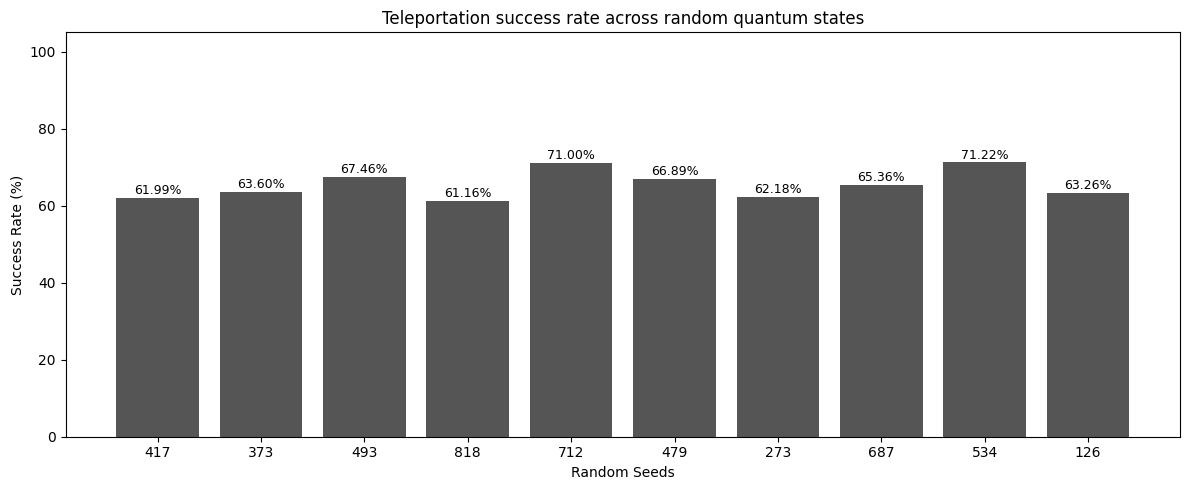

In [8]:
success_rates = []
for result in res:
    z_counts = result[0].data.z.get_counts()
    total_shots = sum(z_counts.values())
    
    # Success is when Bob's z register is measured as all zeros
    success_count = sum(amount for state, amount in z_counts.items() if int(state, 2) == 0)
    success_rates.append((success_count / total_shots) * 100 if total_shots else 0)
    
print(f"Highest success rate: {max(success_rates):.2f}%")
print(f"Lowest success rate: {min(success_rates):.2f}%")
print(f"Average success rate: {sum(success_rates) / len(success_rates):.2f}%")

fig = plt.figure(figsize=(12, 5))
plt.bar([str(s) for s in seeds_used], success_rates, color='#555555')
plt.xlabel("Random Seeds")
plt.ylabel("Success Rate (%)")
plt.title("Teleportation success rate across random quantum states")
plt.ylim(0, 105)

for i, v in enumerate(success_rates):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=9)

plt.tight_layout()
fig.savefig("results/qudit_kingston_random_seeds.png", dpi=600)
plt.show()